   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       6   117444          424            21760   
1            2   69  Female       5    19619          405            56534   
2            3   46    Male       6   193753          881            94991   
3            4   32    Male       9   182570          823            76675   
4            5   60    Male       2    19321          570            29305   

   NumOfProducts  IsActiveMember  Churn  
0              1               0      1  
1              3               0      1  
2              2               1      0  
3              3               1      0  
4              3               1      0  
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Customer_ID         int64
Age                 int64
Gend

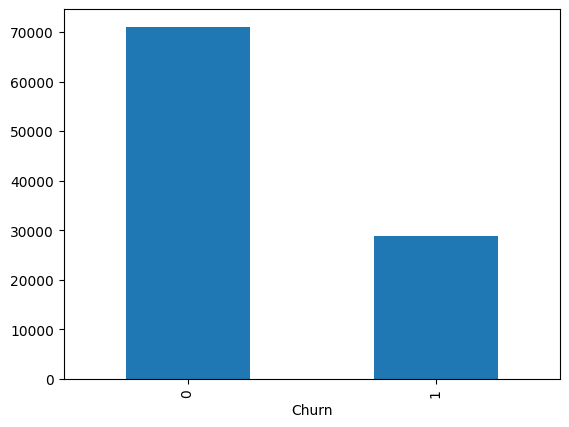

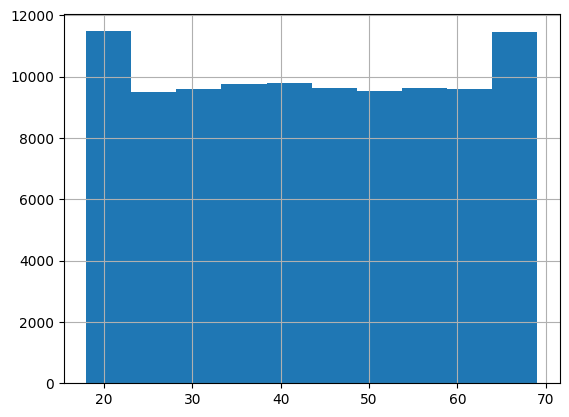

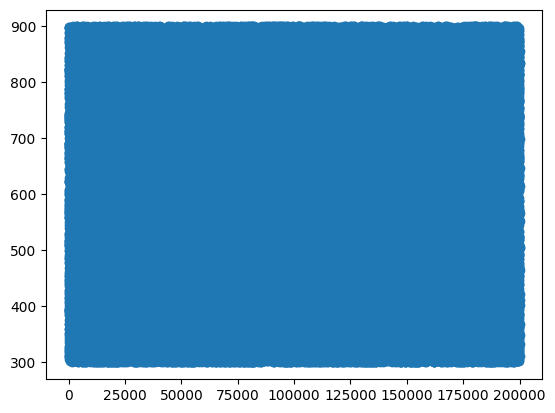

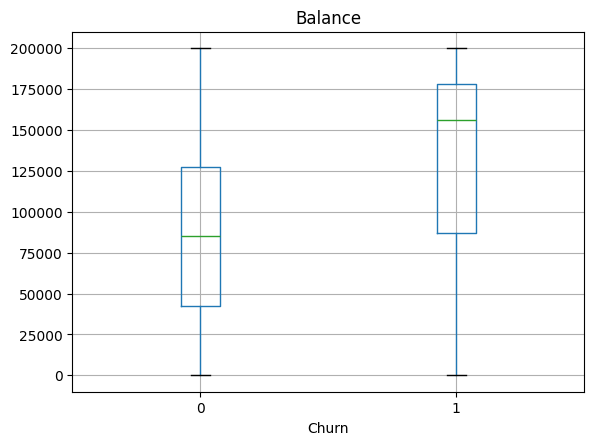

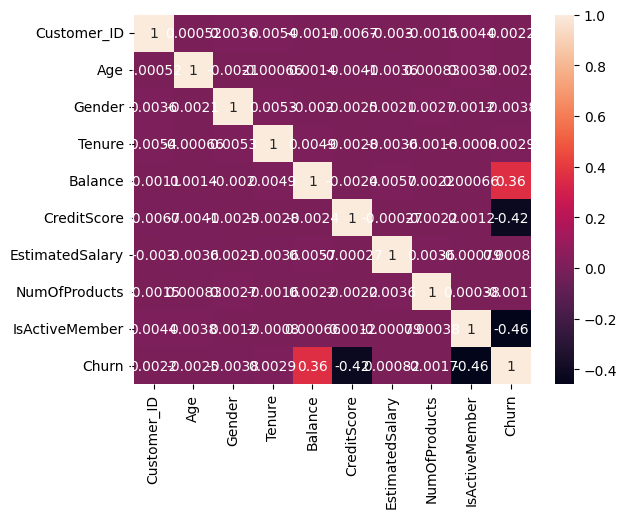

Customers with low credit score, high balance, and inactive status are more likely to churn.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n=100000

data={
"Customer_ID":np.arange(1,n+1),
"Age":np.random.randint(18,70,n),
"Gender":np.random.choice(["Male","Female"],n),
"Tenure":np.random.randint(0,11,n),
"Balance":np.random.randint(0,200000,n),
"CreditScore":np.random.randint(300,900,n),
"EstimatedSalary":np.random.randint(10000,150000,n),
"NumOfProducts":np.random.randint(1,5,n),
"IsActiveMember":np.random.choice([0,1],n)
}

df=pd.DataFrame(data)

df["Churn"]=(
(df["Balance"]>150000).astype(int)+
(df["IsActiveMember"]==0).astype(int)+
(df["CreditScore"]<500).astype(int)
)
df["Churn"]=(df["Churn"]>1).astype(int)

print(df.head())

print(df.isnull().sum())
print(df.dtypes)

df["Gender"]=df["Gender"].map({"Male":0,"Female":1})

print(df.describe())

print(df["Churn"].value_counts())

high_churn=df[df["Churn"]==1]
low_churn=df[df["Churn"]==0]

print(high_churn.mean(numeric_only=True))
print(low_churn.mean(numeric_only=True))

print(pd.crosstab(df["Gender"],df["Churn"]))
print(pd.crosstab(df["IsActiveMember"],df["Churn"]))
print(pd.crosstab(df["NumOfProducts"],df["Churn"]))

df["AgeGroup"]=pd.cut(df["Age"],bins=[18,30,45,60,70],labels=["18-30","30-45","45-60","60-70"])
print(pd.crosstab(df["AgeGroup"],df["Churn"]))

df["Churn"].value_counts().plot(kind="bar")
plt.show()

df["Age"].hist()
plt.show()

plt.scatter(df["Balance"],df["CreditScore"])
plt.show()

df.boxplot(column="Balance",by="Churn")
plt.suptitle("")
plt.show()

sns.heatmap(df.select_dtypes(include=["number"]).corr(),annot=True)
plt.show()

print("Customers with low credit score, high balance, and inactive status are more likely to churn.")